# Hepatitis C Detection
Dataset: Hepatitis C Prediction Dataset (UCI/Kaggle)  
Target: `Category` (0=Blood Donor→healthy, 1/2/3/4=hepatitis stages→positive)

## 1 · Imports & Data Load

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier
import joblib, json

df = pd.read_csv("../data/hepatitis_c.csv")
df.columns = df.columns.str.strip().str.strip('"')
df['target'] = df['Category'].str.strip('"').str.strip().apply(
    lambda x: 0 if '0=Blood Donor' in str(x) else 1)
print(df.shape)
print("Class balance:", df['target'].value_counts().to_dict())
df.head()

(615, 15)
Class balance: {0: 533, 1: 82}


,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,target
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,0
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,0
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7,0
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7,0


In [2]:
for col in ['Age','ALT','AST','ALB','BIL','CHE']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print("Missing values after coerce:")
print(df[['Age','ALT','AST','ALB','BIL','CHE']].isnull().sum())

Missing values after coerce:
Age    0
ALT    1
AST    0
ALB    1
BIL    0
CHE    0
dtype: int64


## 2 · EDA

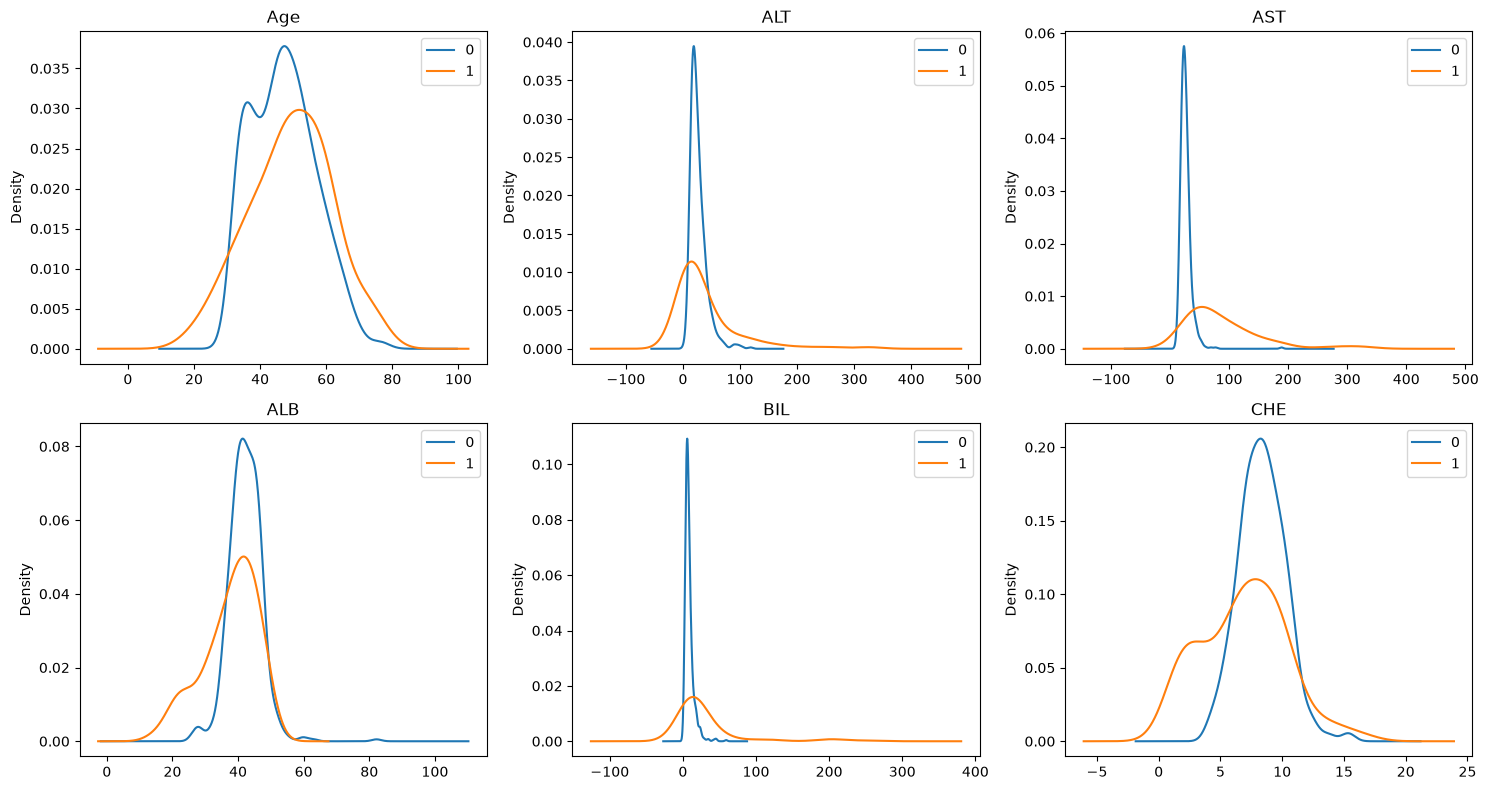

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(['Age','ALT','AST','ALB','BIL','CHE']):
    ax = axes[i//3][i%3]
    df.groupby('target')[col].plot(kind='kde', ax=ax, legend=True, title=col)
plt.tight_layout(); plt.show()

## 3 · Feature Engineering & Field Mapping


In [4]:
X = df[['Age','ALT','AST','ALB','BIL','CHE']].rename(columns={
    'Age':'age','ALT':'alt','AST':'ast','ALB':'alb','BIL':'bil','CHE':'che'})
y = df['target']
print("Feature shape:", X.shape)
print("Missing after rename:", X.isnull().sum().to_dict())

Feature shape: (615, 6)
Missing after rename: {'age': 0, 'alt': 1, 'ast': 0, 'alb': 1, 'bil': 0, 'che': 0}


## 4–5 · Preprocessing & Split 

In [5]:
def make_pipe(clf):
    return Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler',  StandardScaler()), ('clf', clf)])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (492, 6), Test: (123, 6)


## 6 · Model Training & Comparison

In [8]:
candidates = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost':            XGBClassifier(n_estimators=200, random_state=42,
                                        eval_metric='logloss', verbosity=0),
}
results = {}; pipes = {}
for name, clf in candidates.items():
    p = make_pipe(clf); p.fit(X_train, y_train)
    yp = p.predict(X_test); ypr = p.predict_proba(X_test)[:,1]
    results[name] = {'accuracy': round(accuracy_score(y_test,yp),4),
                     'precision': round(precision_score(y_test,yp),4),
                     'recall': round(recall_score(y_test,yp),4),
                     'f1': round(f1_score(y_test,yp),4),
                     'roc_auc': round(roc_auc_score(y_test,ypr),4)}
    pipes[name] = p
pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)

,accuracy,precision,recall,f1,roc_auc
XGBoost,0.9919,1.0000,0.9375,0.9677,0.9965
LogisticRegression,0.9431,1.0000,0.5625,0.7200,0.9912
RandomForest,0.9675,0.9286,0.8125,0.8667,0.9845


## 7 · Evaluation

Best: XGBoost


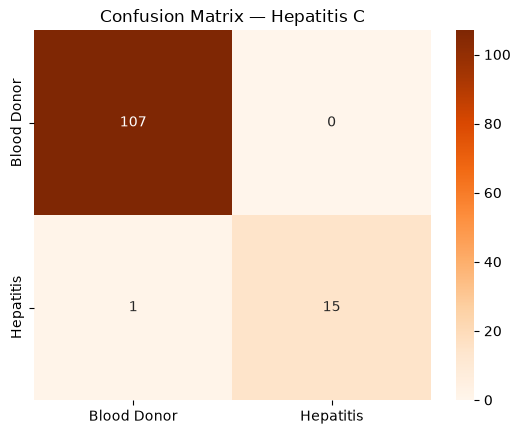

              precision    recall  f1-score   support

 Blood Donor       0.99      1.00      1.00       107
   Hepatitis       1.00      0.94      0.97        16

    accuracy                           0.99       123
   macro avg       1.00      0.97      0.98       123
weighted avg       0.99      0.99      0.99       123



In [9]:
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best = pipes[best_name]; print(f"Best: {best_name}")
y_pred = best.predict(X_test); y_proba = best.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Blood Donor','Hepatitis'], yticklabels=['Blood Donor','Hepatitis'])
plt.title('Confusion Matrix — Hepatitis C'); plt.show()
print(classification_report(y_test, y_pred, target_names=['Blood Donor','Hepatitis']))

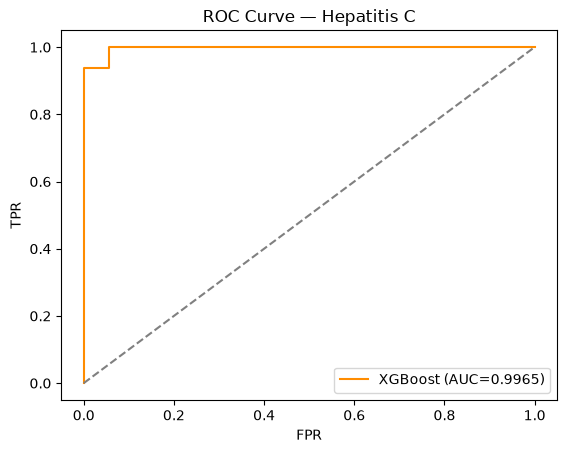

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'{best_name} (AUC={results[best_name]["roc_auc"]})', color='darkorange')
plt.plot([0,1],[0,1],'--',color='grey'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve — Hepatitis C'); plt.legend(); plt.show()

## 8 · Save

In [12]:
joblib.dump(best, '../models/hepatitis_model.joblib')
metrics = {**results[best_name], 'model': best_name,
           'features': list(X.columns), 'test_size': 0.2, 'random_state': 42}
with open('../metrics/hepatitis_metrics.json','w') as f: json.dump(metrics,f,indent=2)